# ANÁLISIS DE DATOS

En este notebook, vamos a realizar distintos análisis con los datos ya recolectados y limpios.

In [1]:
# librerías a utilizar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path

In [2]:
ruta_unificada_micro = Path('csv_unificado_micro') / 'datos_unificados_micro.csv'
ruta_unificada_metro = Path('csv_unificado_metro') / 'datos_unificados_metro.csv'
ruta_paradero_limpio = Path('data') / 'paraderos_limpios.csv'


# Lectura de archivos
Leemos cada archivo correspondiente:

In [3]:
micro_data = pd.read_csv(ruta_unificada_micro)
micro_data.head(3)

,bus_stop_code,route_id,bus_id,meters_distance,min_arrival_time,max_arrival_time,date,X,Y,Hour_minute
0,PB1013,B12,SKDG-90,7520,16,24,2025-10-12 19:01:28.530087,341227.257,6310702.634,19:01
1,PB1013,B33,SKPP-55,2951,8,10,2025-10-12 19:01:28.530094,341227.257,6310702.634,19:01
2,PI725,I10,FLXK-93,2315,7,9,2025-10-12 19:01:30.454781,337333.753,6292318.918,19:01


In [4]:
metro_data = pd.read_csv(ruta_unificada_metro)
metro_data.head(3)

,line_id,station_id,name,status_code,status_description,date,Hora_minuto
0,L1,san-pablo,San Pablo,0,Estación Operativa,2025-10-12 17:07:54.225175,17:07
1,L1,neptuno,Neptuno,0,Estación Operativa,2025-10-12 17:07:54.225191,17:07
2,L1,pajaritos,Pajaritos,0,Estación Operativa,2025-10-12 17:07:54.225193,17:07


In [5]:
recorridos_limpios = pd.read_csv(ruta_paradero_limpio)
recorridos_limpios.head(3)

C:\Users\Carito\AppData\Local\Temp\ipykernel_23824\3400555125.py:1: DtypeWarning: Columns (32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  recorridos_limpios = pd.read_csv(ruta_paradero_limpio)


,bus_stop_code,route_id,bus_id,meters_distance,min_arrival_time,max_arrival_time,date,Hour_minute,id,codinfra,...,11,12,13,14,15,16,17,18,19,20
0,PB1013,B12,SKDG-90,7520,16,24,2025-10-12 19:01:28.530087,19:01,8983,L-6-39-30-OP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PB1013,B33,SKPP-55,2951,8,10,2025-10-12 19:01:28.530094,19:01,8983,L-6-39-30-OP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PI725,I10,FLXK-93,2315,7,9,2025-10-12 19:01:30.454781,19:01,4883,L-13-68-5-OP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Vemos cómo están dados nuestros datos:
recorridos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276624 entries, 0 to 276623
Data columns (total 36 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   bus_stop_code     276624 non-null  object 
 1   route_id          276624 non-null  object 
 2   bus_id            276624 non-null  object 
 3   meters_distance   276624 non-null  int64  
 4   min_arrival_time  276624 non-null  int64  
 5   max_arrival_time  276624 non-null  int64  
 6   date              276624 non-null  object 
 7   Hour_minute       276624 non-null  object 
 8   id                276624 non-null  int64  
 9   codinfra          276624 non-null  object 
 10  comuna            276624 non-null  object 
 11  nombre_par        276624 non-null  object 
 12  n_servicios       276624 non-null  int64  
 13  lan               276624 non-null  float64
 14  lon               276624 non-null  float64
 15  0                 276624 non-null  object 
 16  1                 24

In [7]:
# Revisamos todos los datos que tenemos en los paraderos limpios:
recorridos_limpios.columns

Index(['bus_stop_code', 'route_id', 'bus_id', 'meters_distance',
       'min_arrival_time', 'max_arrival_time', 'date', 'Hour_minute', 'id',
       'codinfra', 'comuna', 'nombre_par', 'n_servicios', 'lan', 'lon', '0',
       '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20'],
      dtype='object')

Entonces, el máximo de recorridos que pasan por uno de los paraderos contenidos en nuestro DataFrame es de 21.

# ANÁLISIS PARCIAL DE DATOS:
Lo primero que haremos, será crear DataFrames por sector de nuestros datos:

In [8]:
recorrido_poniente = recorridos_limpios[recorridos_limpios['comuna'].isin(['QUINTA NORMAL', 'CERRO NAVIA', 'MAIPÚ', 'CERRILLOS',
                                                     'ESTACIÓN CENTRAL', 'PUDAHUEL', 'RENCA', 'LO PRADO',
                                                     'PADRE HURTADO'])]
recorrido_poniente['comuna'].value_counts()

comuna
MAIPÚ               22638
PUDAHUEL             9633
ESTACIÓN CENTRAL     8863
QUINTA NORMAL        7829
RENCA                7359
CERRO NAVIA          7328
CERRILLOS            6190
LO PRADO             4289
PADRE HURTADO         369
Name: count, dtype: int64

In [9]:
# COMUNAS ORIENTE
recorrido_oriente = recorridos_limpios[recorridos_limpios['comuna'].isin(['PROVIDENCIA', 'ÑUÑOA', 'LA REINA', 'LAS CONDES',
                                                                  'VITACURA', 'LO BARNECHEA', 'PEÑALOLÉN', 'MACUL',
                                                                  'LA FLORIDA', 'PUENTE ALTO'])]
recorrido_oriente['comuna'].value_counts()

comuna
PUENTE ALTO     21526
LAS CONDES      14384
LA FLORIDA      14117
PEÑALOLÉN       10397
ÑUÑOA            8392
PROVIDENCIA      7062
LA REINA         5919
MACUL            5592
VITACURA         4442
LO BARNECHEA     3115
Name: count, dtype: int64

In [10]:
# SECTOR SUR
recorrido_sur = recorridos_limpios[recorridos_limpios['comuna'].isin(['PEDRO AGUIRRE CERDA', 'SAN MIGUEL',
                                                              'SAN JOAQUÍN', 'LO ESPEJO', 'LA CISTERNA',
                                                              'LA GRANJA', 'SAN RAMÓN', 'EL BOSQUE',
                                                              'SAN BERNARDO', 'LA CISTERNA'])]
recorrido_sur['comuna'].value_counts()

comuna
SAN BERNARDO           10384
EL BOSQUE               6649
LA GRANJA               5157
LO ESPEJO               5011
LA CISTERNA             4935
SAN MIGUEL              4650
SAN RAMÓN               4203
PEDRO AGUIRRE CERDA     3882
SAN JOAQUÍN             3719
Name: count, dtype: int64

In [11]:
# SECTOR NORTE
recorrido_norte = recorridos_limpios[recorridos_limpios['comuna'].isin(['CONCHALÍ', 'HUECHURABA', 'INDEPENDENCIA', 'RECOLETA', 'QUILICURA'])]
recorrido_norte['comuna'].value_counts()

comuna
QUILICURA        9887
CONCHALÍ         6219
RECOLETA         5868
HUECHURABA       4303
INDEPENDENCIA    3837
Name: count, dtype: int64

In [12]:
# Revisaremos la mediana de los metros de distancia por sector
mediana_tiempo_norte = recorrido_norte.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_tiempo_sur = recorrido_sur.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_tiempo_oriente = recorrido_oriente.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_tiempo_poniente = recorrido_poniente.groupby(by='Hour_minute').agg({'meters_distance': 'median'})
mediana_oriente_poniente = pd.merge(mediana_tiempo_oriente, mediana_tiempo_poniente, on='Hour_minute', how='outer')
mediana_oriente_poniente = mediana_oriente_poniente.set_axis(['Sector Oriente', 'Sector Poniente'], axis= 1)
mediana_norte_sur = pd.merge(mediana_tiempo_norte, mediana_tiempo_sur, on='Hour_minute', how='outer')
mediana_norte_sur = mediana_norte_sur.set_axis(['Sector Norte', 'Sector Sur'], axis= 1)
mediana_por_sector = pd.merge(mediana_norte_sur, mediana_oriente_poniente, on='Hour_minute', how='outer')
mediana_por_sector.drop(mediana_por_sector.index[2], inplace=True)
mediana_por_sector

,Sector Norte,Sector Sur,Sector Oriente,Sector Poniente
Hour_minute,,,,
06:00,4104.0,3480.0,4059.0,4735.5
08:00,2637.0,2510.0,2386.0,2972.0
10:00,2750.5,2801.0,2472.5,3177.0
12:00,2852.0,2794.0,2693.5,3103.0
14:00,2602.5,2718.0,2575.0,2964.0
16:00,2950.5,2789.0,2635.0,2965.5
18:00,2404.0,2525.5,2348.5,2717.0
19:01,3895.0,3820.0,4012.0,4420.0
20:00,2753.0,2810.0,2705.0,2982.0


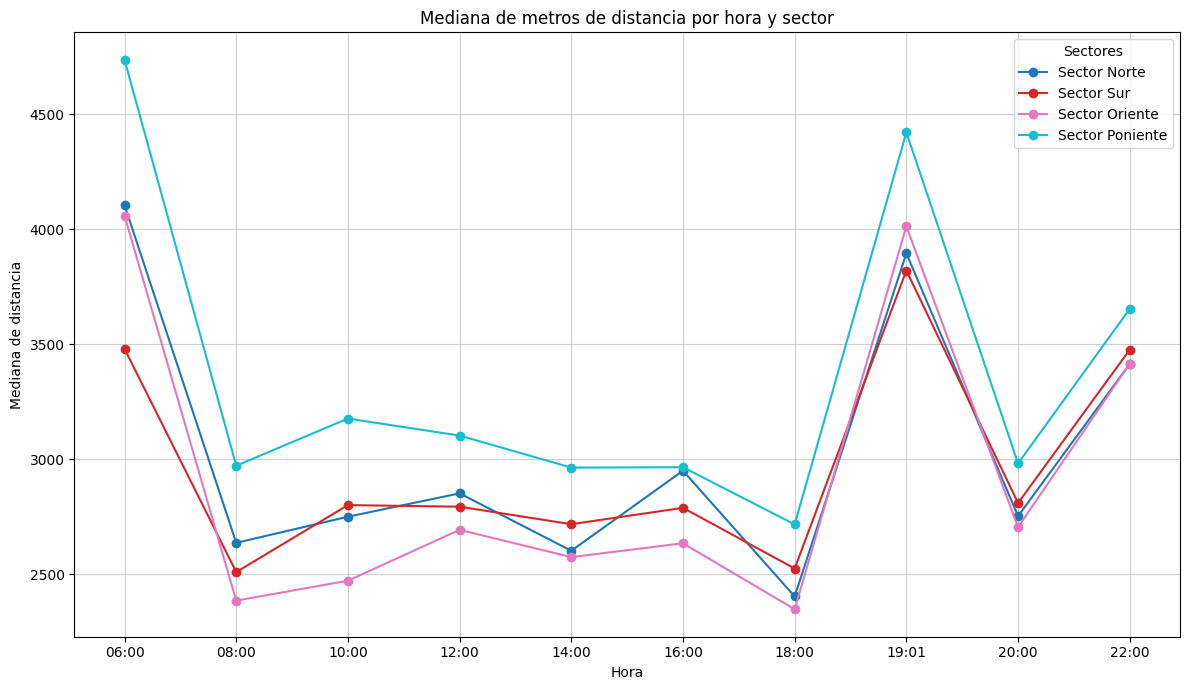

In [13]:
plt.figure(figsize=(12,7))

# Graficamos todas las columnas por sector
colormap = plt.colormaps['tab10']
for i, columna in enumerate(mediana_por_sector.columns):
    plt.plot(mediana_por_sector.index,
            mediana_por_sector[columna],
            marker='o',
            label=columna,
            color = colormap(i / (len(mediana_por_sector.columns) - 1)))

plt.title("Mediana de metros de distancia por hora y sector")
plt.xlabel("Hora")
plt.ylabel("Mediana de distancia")
plt.legend(title="Sectores")
plt.grid(True, linestyle='-', alpha=0.6)
plt.tight_layout()

plt.show()

In [17]:
distancia_norte = recorrido_norte.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_norte['DISTANCIA_MIN'] = distancia_norte.min(axis=1)
distancia_norte['DISTANCIA_MAX'] = distancia_norte.max(axis=1)
distancia_norte['RANGO_DESBALANCE'] = distancia_norte.max(axis=1) - distancia_norte.min(axis=1) 
distancia_norte.sort_index()

comuna,CONCHALÍ,HUECHURABA,INDEPENDENCIA,QUILICURA,RECOLETA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,
06:00,3916.0,4895.0,3619.0,4138.5,4008.0,3619.0,4895.0,1276.0
08:00,3245.0,3308.0,2367.0,2125.0,2341.5,2125.0,3308.0,1183.0
08:40,2046.0,2750.0,1842.0,2379.0,2293.5,1842.0,2750.0,908.0
10:00,3073.5,2961.5,2451.0,2760.0,2420.0,2420.0,3073.5,653.5
12:00,3145.5,3017.0,2499.0,2848.5,2617.0,2499.0,3145.5,646.5
14:00,2956.0,3197.0,2549.0,2428.0,2431.0,2428.0,3197.0,769.0
16:00,3181.0,3121.0,2879.5,2585.0,3093.0,2585.0,3181.0,596.0
18:00,2656.0,2896.0,2661.0,2211.0,2154.0,2154.0,2896.0,742.0
19:01,5889.5,5510.0,4240.0,2841.0,3337.5,2841.0,5889.5,3048.5


In [18]:
distancia_sur = recorrido_sur.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_sur['DISTANCIA_MIN'] = distancia_sur.min(axis=1)
distancia_sur['DISTANCIA_MAX'] = distancia_sur.max(axis=1)
distancia_sur['RANGO_DESBALANCE'] = distancia_sur.max(axis=1) - distancia_sur.min(axis=1) 
distancia_sur.sort_index()

comuna,EL BOSQUE,LA CISTERNA,LA GRANJA,LO ESPEJO,PEDRO AGUIRRE CERDA,SAN BERNARDO,SAN JOAQUÍN,SAN MIGUEL,SAN RAMÓN,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,,,,,
06:00,2724.0,3048.0,3544.0,3593.0,3615.0,3722.0,3713.5,4038.0,3924.0,2724.0,4038.0,1314.0
08:00,2034.0,2759.0,2526.0,2435.5,3220.5,2362.0,2844.5,2591.0,2388.5,2034.0,3220.5,1186.5
08:40,2097.0,2130.5,2683.0,3322.0,2248.0,2946.0,2977.0,2480.5,2041.0,2041.0,3322.0,1281.0
10:00,2581.5,2912.0,2767.0,2780.0,3057.0,2985.0,2738.0,2523.5,2874.0,2523.5,3057.0,533.5
12:00,2564.0,2634.0,2850.0,2816.0,3179.0,2828.0,2930.5,2688.0,2738.0,2564.0,3179.0,615.0
14:00,2011.0,2478.0,3047.0,2689.0,3120.5,2720.0,2921.0,2643.0,2958.5,2011.0,3120.5,1109.5
16:00,2463.0,2470.0,2803.0,2988.0,3359.5,2993.0,2765.0,2733.0,2614.0,2463.0,3359.5,896.5
18:00,2217.5,2115.5,2713.0,2798.5,2760.0,2477.0,2924.5,2515.0,2653.5,2115.5,2924.5,809.0
19:01,4495.0,3617.0,3425.0,4135.0,5564.5,2174.0,5557.0,2770.0,3973.0,2174.0,5564.5,3390.5


In [19]:
distancia_oriente = recorrido_oriente.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_oriente['DISTANCIA_MIN'] = distancia_oriente.min(axis=1)
distancia_oriente['DISTANCIA_MAX'] = distancia_oriente.max(axis=1)
distancia_oriente['RANGO_DESBALANCE'] = distancia_oriente.max(axis=1) - distancia_oriente.min(axis=1) 
distancia_oriente.sort_index()

comuna,LA FLORIDA,LA REINA,LAS CONDES,LO BARNECHEA,MACUL,PEÑALOLÉN,PROVIDENCIA,PUENTE ALTO,VITACURA,ÑUÑOA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,,,,,,
06:00,3284.0,4619.0,4297.0,4827.0,4090.0,5099.0,4385.5,3466.0,4658.0,4618.0,3284.0,5099.0,1815.0
08:00,2275.0,2304.0,2195.5,2357.0,2966.0,2697.0,1960.0,2371.0,2871.0,2371.5,1960.0,2966.0,1006.0
08:40,2132.0,2333.0,1794.0,2212.0,1886.0,2465.0,1327.0,2141.0,1906.0,2175.0,1327.0,2465.0,1138.0
10:00,2594.5,2472.0,2173.0,2280.0,2906.0,2773.0,2106.0,2578.5,2391.0,2305.0,2106.0,2906.0,800.0
12:00,2810.0,2649.5,2790.0,2736.0,2632.0,2812.0,2761.0,2643.0,2568.0,2492.0,2492.0,2812.0,320.0
14:00,2526.0,2710.0,2581.5,2256.0,2685.0,2783.0,2330.0,2552.0,3043.0,2445.0,2256.0,3043.0,787.0
16:00,2493.5,2983.0,2643.0,2532.0,2812.0,2709.0,2499.0,2617.0,3115.5,2481.0,2481.0,3115.5,634.5
18:00,2303.0,2537.0,2192.5,2210.5,2517.0,2549.0,2184.0,2407.0,2491.0,2126.0,2126.0,2549.0,423.0
19:01,3521.0,4910.0,3623.5,4845.0,6076.0,4157.0,3769.5,3762.5,3557.0,4238.0,3521.0,6076.0,2555.0


In [20]:
distancia_poniente = recorrido_poniente.pivot_table(index='Hour_minute', columns='comuna', values='meters_distance', aggfunc='median')
distancia_poniente['DISTANCIA_MIN'] = distancia_poniente.min(axis=1)
distancia_poniente['DISTANCIA_MAX'] = distancia_poniente.max(axis=1)
distancia_poniente['RANGO_DESBALANCE'] = distancia_poniente.max(axis=1) - distancia_poniente.min(axis=1) 
distancia_poniente.sort_index()

comuna,CERRILLOS,CERRO NAVIA,ESTACIÓN CENTRAL,LO PRADO,MAIPÚ,PADRE HURTADO,PUDAHUEL,QUINTA NORMAL,RENCA,DISTANCIA_MIN,DISTANCIA_MAX,RANGO_DESBALANCE
Hour_minute,,,,,,,,,,,,
06:00,4612.0,6593.5,4513.0,5026.5,4608.0,1790.0,4850.5,4698.0,4360.0,1790.0,6593.5,4803.5
08:00,3719.0,2915.0,2888.0,2541.0,2688.0,1433.0,3030.5,3605.5,2980.0,1433.0,3719.0,2286.0
08:40,3021.0,2025.0,2637.5,1898.0,2606.0,1844.5,2485.0,3470.0,2223.0,1844.5,3470.0,1625.5
10:00,3834.0,3064.0,3117.5,3093.0,3052.0,1550.0,3580.5,3097.0,3151.0,1550.0,3834.0,2284.0
12:00,3741.5,3063.0,3007.0,2953.5,2988.5,1654.0,3267.5,3260.0,2927.0,1654.0,3741.5,2087.5
14:00,3665.5,2911.0,2614.0,3092.0,2695.0,939.0,3160.0,3024.0,3288.0,939.0,3665.5,2726.5
16:00,3875.0,2874.0,2921.0,2937.5,2766.5,1288.5,3146.0,2979.0,3302.5,1288.5,3875.0,2586.5
18:00,3239.0,2742.5,2668.0,2205.0,2799.0,1168.0,2524.0,2772.0,2886.0,1168.0,3239.0,2071.0
19:01,4193.5,3624.5,4541.0,4233.5,3956.5,3755.5,5004.0,4665.0,4192.0,3624.5,5004.0,1379.5
